# Evaluation
We will be evaluating both our simple model as well as the best advanced model against the test set, as well as the LIAR dataset.

In [1]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score
from sklearn_transformers import *
from pathlib import Path
from joblib import load
import pandas as pd

MODELS_DIR = Path("data/models")
DATA_DIR = Path("data")
PREPROCESSED_DIR = DATA_DIR / "preprocessed"
TOKENIZER_DIR = PREPROCESSED_DIR / "tokenizers"

SIMPLE_MODEL = MODELS_DIR / "simple_model.joblib"
ADVANCED_MODEL = MODELS_DIR / "advanced_logreg.joblib"

## Loading the models

In [2]:
simple_pipeline : Pipeline = load(SIMPLE_MODEL)

simple_pipeline

,steps,"[('preprocess', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('tokenize', ...), ('vectorize', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformer,TokenTransfor... top_n=10000)
,top_n,10000
,special_tokens,"['<NUM>', '<DATE>', ...]"


In [3]:
# Functions needed for TfidfVectorizer
def ids_to_tokens(doc):
    return [str(tok) for tok in doc]
def identity(doc):
    return doc

advanced_pipeline : Pipeline = load(ADVANCED_MODEL)
advanced_pipeline

,steps,"[('preprocess', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('tokenize', ...), ('tfidf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformer,TokenTransfor... top_n=10000)
,top_n,10000
,special_tokens,"['<NUM>', '<DATE>', ...]"


## Evaluation

### Test split

In [4]:
df = pd.read_csv(PREPROCESSED_DIR / "splits" / "test.csv")
df.head(2)

,id,domain,type,url,content,title,is_reliable
0,3843586.0,president45donaldtrump.com,fake,http://president45donaldtrump.com/19-03-0/,via| perhaps the most solemn and awe-inspiring...,"memorial day: honor guard hears disrespect, pu...",0
1,76290.0,beforeitsnews.com,fake,http://beforeitsnews.com/eu/2013/07/unite-agai...,unite against the vested interests headline: b...,unite against the vested interests,0


#### Predictions

In [5]:
fakenews_simple_y_pred = simple_pipeline.predict(df)

100%|██████████| 79337/79337 [00:02<00:00, 29882.56it/s]


In [6]:
fakenews_advanced_y_pred = advanced_pipeline.predict(df)

100%|██████████| 79337/79337 [00:36<00:00, 2191.28it/s]


#### Performance

We will be visualizing these scores using a heatmap

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from typing import Sequence

def make_confusion_matrix(
        y_true: Sequence[int],
        y_pred_simple : Sequence[int],
        y_pred_adv : Sequence[int],
        labels: Tuple[str, str] = ("real", "fake")):
    cm_simple = confusion_matrix(y_true, y_pred_simple, normalize="true")
    cm_advanced = confusion_matrix(y_true, y_pred_adv, normalize="true")

    fig, axes = plt.subplots(1, 2, figsize=(7, 3))
    sns.heatmap(cm_simple, annot=True, cmap="Blues", xticklabels=labels, yticklabels=labels, cbar=False, ax=axes[0])
    axes[0].set_title("Simple model")
    axes[0].set_xlabel("Predicted label")
    axes[0].set_ylabel("True label")

    sns.heatmap(cm_advanced, annot=True, cmap="Blues", xticklabels=labels, yticklabels=labels, cbar=True, ax=axes[1])
    axes[1].set_title("Advanced model")
    axes[1].set_xlabel("Predicted label")
    axes[1].set_ylabel("True label")

    plt.tight_layout()
    plt.show()
    print("[*] Simple model F1-score: ", f1_score(y_true, y_pred_simple))
    print("[*] Advanced model F1-score: ", f1_score(y_true, y_pred_adv))

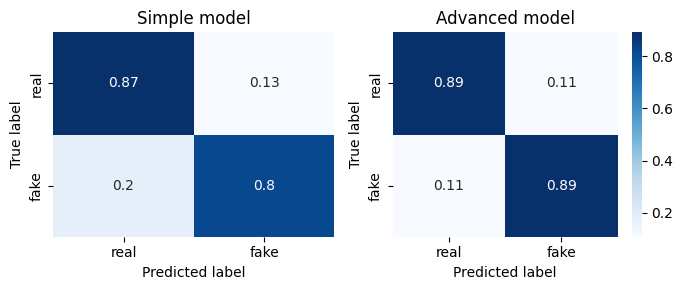

[*] Simple model F1-score:  0.8311445869038204
[*] Advanced model F1-score:  0.8915396952686447


In [8]:
make_confusion_matrix(
    df["is_reliable"].to_numpy(), 
    fakenews_simple_y_pred, 
    fakenews_advanced_y_pred)

As we can see there isn't really any types of errors that are way more common than the other, especially for the advanced model. The simple model has a little higher tendency to predict fake positives than fake negatives, but a difference of $0.07$ is most likely just due to noise.

### LIAR dataset

Before we can evaluate our model on the LIAR dataset, we have to perform some simple preprocessing

In [9]:
from sklearn.pipeline import Pipeline
from sklearn_transformers import *

def clean_liar(path: Path, reliables : list[str] = ['true', 'mostly-true', "half-true"]) -> pd.DataFrame:
    clean_pipeline = Pipeline([
        ("filter", FilterTransformer(drop_cols=range(14), remove_nulls_col_names=["type", "content"], deduplicate_cols=["content"], 
                                     convert_to_category_cols=["type"], remove_cols_with_value={})),
        ("clean", CleaningTransformer())
    ])

    df = pd.read_csv(path / "train.tsv", sep='\t', header=None)
    df['content'] = df[2]
    df['type'] = df[1]
    df['id'] = df[0].map(lambda x: 0) # necessary for cleaning pipeline
    df['title'] = df[5] # necessary for cleaning pipeline
    
    cleaned = clean_pipeline.fit_transform(df)
    return pd.DataFrame({
        'content': cleaned["content"],
        'is_reliable' : cleaned['type'].map(lambda t: t in reliables)
    })

In [10]:
df_liar = clean_liar(DATA_DIR / "LIAR")
print(df_liar.head(3))

print("processing LIAR data")
liar_y_true = df_liar['is_reliable']
liar_simple_y_pred = simple_pipeline.predict(df_liar)
liar_advanced_y_pred = advanced_pipeline.predict(df_liar)

                                             content  is_reliable
0  says the annies list political group supports ...        False
1  when did the decline of coal start? it started...         True
2  hillary clinton agrees with john mccain "by vo...         True
processing LIAR data


100%|██████████| 10223/10223 [00:00<00:00, 46779.96it/s]


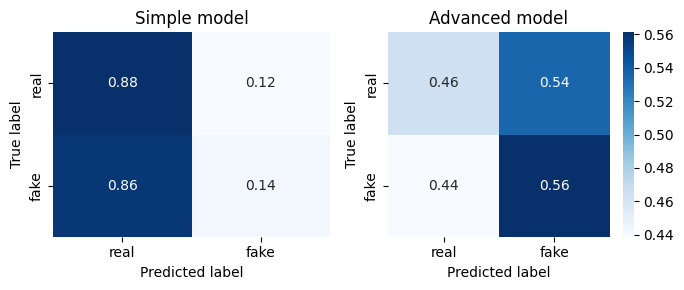

[*] Simple model F1-score:  0.22587036512878572
[*] Advanced model F1-score:  0.5671300369523139


In [11]:
make_confusion_matrix(liar_y_true, liar_simple_y_pred, liar_advanced_y_pred)